# Part 3 – Advanced Modeling

In this notebook, I explore different ensemble learning techniques and compare their performance with the models built in Part 2. I also evaluate different Decision Tree configurations and prepare the dataset for model tuning and pipeline construction.

## Importing the Required Libraries

The following libraries are required for preprocessing, model training, cross-validation, hyperparameter tuning, serialization and performance evaluation.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import io
from google.colab import files

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import make_pipeline

from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve
)

import joblib

plt.style.use("ggplot")

## Loading the Dataset

The cleaned dataset from Part 1 is uploaded and loaded into a pandas DataFrame.

In [2]:
print("Upload cleaned_data.csv")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(df.head())

print(df.shape)

Upload cleaned_data.csv


Saving cleaned_data.csv to cleaned_data.csv
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sal

## Preparing the Data

The regression target remains the house sale price. A binary classification target is created using the median sale price, where houses above the median belong to class 1 and the remaining houses belong to class 0.

In [3]:
y_reg = df["SalePrice"]

y_clf = (y_reg > y_reg.median()).astype(int)

X = df.drop("SalePrice", axis=1)

## Encoding Categorical Features

Machine learning models require numerical input, so all categorical variables are converted into numerical form using one-hot encoding.

In [4]:
categorical_columns = X.select_dtypes(
    include=["object","category"]
).columns

X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print(X.shape)

(2930, 262)


## Splitting the Dataset

The dataset is divided into training and testing sets using an 80:20 ratio.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_clf,
    test_size=0.20,
    random_state=42
)

## Feature Scaling

The scaler is fitted only on the training data and then applied to both the training and testing datasets.

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Decision Tree Baseline

A Decision Tree classifier is trained using the default parameters. The training and testing accuracy are compared to observe whether the model is overfitting.

In [7]:
tree_default = DecisionTreeClassifier(
    random_state=42
)

tree_default.fit(
    X_train_scaled,
    y_train
)

train_accuracy = accuracy_score(
    y_train,
    tree_default.predict(X_train_scaled)
)

test_accuracy = accuracy_score(
    y_test,
    tree_default.predict(X_test_scaled)
)

print("Decision Tree (Default)")

print(f"Training Accuracy : {train_accuracy:.4f}")

print(f"Testing Accuracy  : {test_accuracy:.4f}")

Decision Tree (Default)
Training Accuracy : 1.0000
Testing Accuracy  : 0.9096


## Controlled Decision Tree

A second Decision Tree is trained with restrictions on its depth and minimum number of samples required for splitting. These constraints help reduce overfitting.

In [8]:
tree_controlled = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

tree_controlled.fit(
    X_train_scaled,
    y_train
)

train_accuracy_controlled = accuracy_score(
    y_train,
    tree_controlled.predict(X_train_scaled)
)

test_accuracy_controlled = accuracy_score(
    y_test,
    tree_controlled.predict(X_test_scaled)
)

print("Controlled Decision Tree")

print(f"Training Accuracy : {train_accuracy_controlled:.4f}")

print(f"Testing Accuracy  : {test_accuracy_controlled:.4f}")

Controlled Decision Tree
Training Accuracy : 0.9249
Testing Accuracy  : 0.9164


## Comparing Decision Trees

The performance of the default and controlled Decision Trees is compared using training and testing accuracy.

In [9]:
tree_results = pd.DataFrame({

    "Model":[
        "Default Tree",
        "Controlled Tree"
    ],

    "Training Accuracy":[
        train_accuracy,
        train_accuracy_controlled
    ],

    "Testing Accuracy":[
        test_accuracy,
        test_accuracy_controlled
    ]

})

tree_results

,Model,Training Accuracy,Testing Accuracy
0,Default Tree,1.000000,0.909556
1,Controlled Tree,0.924915,0.916382


## Gini vs Entropy

Two Decision Tree models are trained using different splitting criteria. Their test accuracy is compared to understand whether the choice of impurity measure affects model performance.

In [10]:
tree_gini = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

tree_entropy = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

tree_gini.fit(
    X_train_scaled,
    y_train
)

tree_entropy.fit(
    X_train_scaled,
    y_train
)

gini_accuracy = accuracy_score(
    y_test,
    tree_gini.predict(X_test_scaled)
)

entropy_accuracy = accuracy_score(
    y_test,
    tree_entropy.predict(X_test_scaled)
)

comparison = pd.DataFrame({

    "Criterion":[
        "Gini",
        "Entropy"
    ],

    "Test Accuracy":[
        gini_accuracy,
        entropy_accuracy
    ]

})

comparison

,Criterion,Test Accuracy
0,Gini,0.921502
1,Entropy,0.921502


## Random Forest Classifier

A Random Forest model is trained to improve prediction performance by combining multiple decision trees. The model is evaluated using training accuracy, testing accuracy and ROC-AUC score.

In [11]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

random_forest.fit(
    X_train_scaled,
    y_train
)

rf_train_pred = random_forest.predict(X_train_scaled)
rf_test_pred = random_forest.predict(X_test_scaled)

rf_train_prob = random_forest.predict_proba(X_train_scaled)[:,1]
rf_test_prob = random_forest.predict_proba(X_test_scaled)[:,1]

rf_train_accuracy = accuracy_score(
    y_train,
    rf_train_pred
)

rf_test_accuracy = accuracy_score(
    y_test,
    rf_test_pred
)

rf_auc = roc_auc_score(
    y_test,
    rf_test_prob
)

print("Random Forest Results")
print("-"*35)
print(f"Training Accuracy : {rf_train_accuracy:.4f}")
print(f"Testing Accuracy  : {rf_test_accuracy:.4f}")
print(f"ROC-AUC Score     : {rf_auc:.4f}")

Random Forest Results
-----------------------------------
Training Accuracy : 0.9872
Testing Accuracy  : 0.9488
ROC-AUC Score     : 0.9903


## Feature Importance

The Random Forest model calculates feature importance based on how much each feature contributes to reducing impurity across all decision trees.

In [12]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": random_forest.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

top5 = importance.head(5)

print(top5)

         Feature  Importance
17   Gr Liv Area    0.081495
7     Year Built    0.074723
5   Overall Qual    0.058105
20     Full Bath    0.049728
27   Garage Cars    0.049572


## Top Five Important Features

The following plot shows the five most influential features according to the Random Forest model.

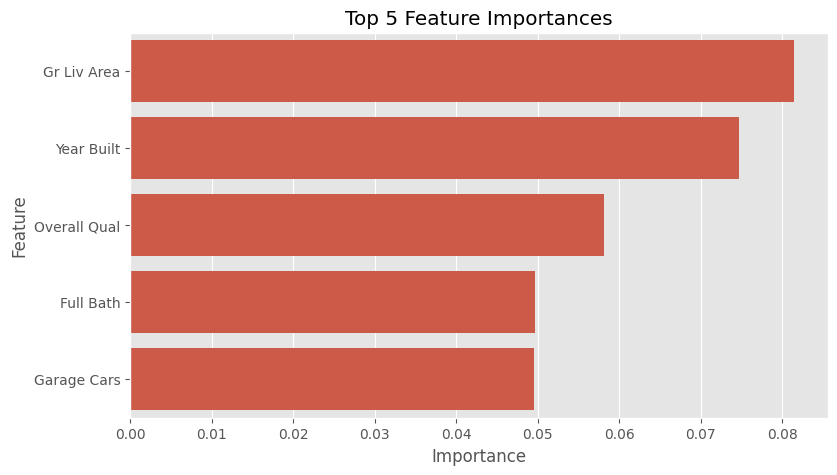

In [13]:
import os

os.makedirs("plots", exist_ok=True)

plt.figure(figsize=(9,5))

sns.barplot(
    data=top5,
    x="Importance",
    y="Feature"
)

plt.title("Top 5 Feature Importances")

plt.savefig(
    "plots/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Gradient Boosting Classifier

Gradient Boosting is another ensemble method that builds trees sequentially, where each new tree attempts to correct the errors made by the previous trees.

In [14]:
gradient_boost = GradientBoostingClassifier(

    n_estimators=100,

    learning_rate=0.1,

    max_depth=3,

    random_state=42

)

gradient_boost.fit(

    X_train_scaled,

    y_train

)

gb_train_pred = gradient_boost.predict(

    X_train_scaled

)

gb_test_pred = gradient_boost.predict(

    X_test_scaled

)

gb_test_prob = gradient_boost.predict_proba(

    X_test_scaled

)[:,1]

In [15]:
gb_train_accuracy = accuracy_score(

    y_train,

    gb_train_pred

)

gb_test_accuracy = accuracy_score(

    y_test,

    gb_test_pred

)

gb_auc = roc_auc_score(

    y_test,

    gb_test_prob

)

print("Gradient Boosting Results")

print("-"*35)

print(f"Training Accuracy : {gb_train_accuracy:.4f}")

print(f"Testing Accuracy  : {gb_test_accuracy:.4f}")

print(f"ROC-AUC Score     : {gb_auc:.4f}")

Gradient Boosting Results
-----------------------------------
Training Accuracy : 0.9748
Testing Accuracy  : 0.9454
ROC-AUC Score     : 0.9907


## Feature Ablation Study

To understand whether the least important features contribute to prediction performance, the five features with the lowest importance scores are removed and a new Random Forest model is trained.

In [16]:
lowest5 = importance.tail(5)

print(lowest5)

                    Feature  Importance
208         Kitchen Qual_Po         0.0
40        MS Zoning_I (all)         0.0
230          Garage Qual_Po         0.0
234          Garage Cond_Po         0.0
257  Sale Condition_AdjLand         0.0


In [17]:
remove_features = lowest5["Feature"].tolist()

X_reduced = X.drop(

    columns=remove_features

)

X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(

    X_reduced,

    y_clf,

    test_size=0.20,

    random_state=42

)

In [18]:
scaler_reduced = StandardScaler()

X_train_reduced_scaled = scaler_reduced.fit_transform(

    X_train_reduced

)

X_test_reduced_scaled = scaler_reduced.transform(

    X_test_reduced

)

In [19]:
rf_reduced = RandomForestClassifier(

    n_estimators=100,

    max_depth=10,

    random_state=42

)

rf_reduced.fit(

    X_train_reduced_scaled,

    y_train_reduced

)

reduced_probability = rf_reduced.predict_proba(

    X_test_reduced_scaled

)[:,1]

reduced_auc = roc_auc_score(

    y_test_reduced,

    reduced_probability

)

print(f"Reduced Model AUC : {reduced_auc:.4f}")

Reduced Model AUC : 0.9912


## Full Model vs Reduced Model

The ROC-AUC scores of the original Random Forest model and the reduced model are compared to determine whether removing the least important features affects prediction performance.

In [20]:
ablation = pd.DataFrame({

    "Model":[

        "Full Random Forest",

        "Reduced Random Forest"

    ],

    "ROC-AUC":[

        rf_auc,

        reduced_auc

    ]

})

ablation

,Model,ROC-AUC
0,Full Random Forest,0.990316
1,Reduced Random Forest,0.991226


## Cross-Validated Model Comparison

To obtain a more reliable estimate of model performance, 5-fold Stratified Cross Validation is performed on four different classifiers.

The evaluation metric used is ROC-AUC.

In [21]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Logistic Regression Cross Validation

The Logistic Regression model from Part 2 is evaluated using five-fold cross validation.

In [40]:
logistic = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_scores = cross_val_score(

    logistic,

    X,

    y_clf,

    cv=cv,

    scoring="roc_auc"

)
# Train the model for later predictions
logistic.fit(X_train_scaled, y_train)

print(logistic_scores)

[0.94087293 0.92599797 0.91930017 0.92167552 0.90780216]


## Decision Tree Cross Validation

The controlled Decision Tree model is evaluated using the same cross-validation strategy.

In [23]:
decision_scores = cross_val_score(

    tree_controlled,

    X,

    y_clf,

    cv=cv,

    scoring="roc_auc"

)

print(decision_scores)

[0.9513448  0.92606786 0.93959161 0.94010926 0.92785505]


## Random Forest Cross Validation

The Random Forest classifier is evaluated using five-fold cross validation.

In [24]:
random_scores = cross_val_score(

    random_forest,

    X,

    y_clf,

    cv=cv,

    scoring="roc_auc"

)

print(random_scores)

[0.98407669 0.9812112  0.98482219 0.98437937 0.97927733]


## Gradient Boosting Cross Validation

The Gradient Boosting model is evaluated using the same evaluation strategy.

In [25]:
gradient_scores = cross_val_score(

    gradient_boost,

    X,

    y_clf,

    cv=cv,

    scoring="roc_auc"

)

print(gradient_scores)

[0.98292351 0.98363406 0.98232944 0.98279517 0.98026745]


## Cross Validation Summary

The mean ROC-AUC and the standard deviation are calculated for every model.

In [26]:
cv_results = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Decision Tree",

        "Random Forest",

        "Gradient Boosting"

    ],

    "Mean AUC":[

        logistic_scores.mean(),

        decision_scores.mean(),

        random_scores.mean(),

        gradient_scores.mean()

    ],

    "Std AUC":[

        logistic_scores.std(),

        decision_scores.std(),

        random_scores.std(),

        gradient_scores.std()

    ]

})

cv_results

,Model,Mean AUC,Std AUC
0,Logistic Regression,0.923130,0.010722
1,Decision Tree,0.936994,0.009223
2,Random Forest,0.982753,0.002151
3,Gradient Boosting,0.982390,0.001141


## Building a Machine Learning Pipeline

A preprocessing pipeline is created using median imputation, feature scaling and a Random Forest classifier.

This pipeline allows all preprocessing and model training steps to be executed together.

In [27]:
pipeline = make_pipeline(

    SimpleImputer(strategy="median"),

    StandardScaler(),

    RandomForestClassifier(
        random_state=42
    )

)

## Hyperparameter Grid

The following parameter combinations are evaluated using Grid Search.

In [28]:
parameter_grid = {

    "randomforestclassifier__n_estimators":[

        50,

        100,

        200

    ],

    "randomforestclassifier__max_depth":[

        5,

        10,

        None

    ],

    "randomforestclassifier__min_samples_leaf":[

        1,

        5

    ]

}

## Grid Search

Grid Search is used to evaluate different combinations of Random Forest hyperparameters using five-fold cross validation.

In [29]:
grid_search = GridSearchCV(

    estimator=pipeline,

    param_grid=parameter_grid,

    cv=cv,

    scoring="roc_auc",

    n_jobs=-1

)

In [30]:
grid_search.fit(

    X_train,

    y_train

)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('simpleimputer',
                                        SimpleImputer(strategy='median')),
                                       ('standardscaler', StandardScaler()),
                                       ('randomforestclassifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'randomforestclassifier__max_depth': [5, 10, None],
                         'randomforestclassifier__min_samples_leaf': [1, 5],
                         'randomforestclassifier__n_estimators': [50, 100,
                                                                  200]},
             scoring='roc_auc')

## Best Hyperparameters

The best parameter combination identified during Grid Search is displayed below.

In [32]:
print("Best Parameters")
print(grid_search.best_params_)

print()
print("Best Cross Validation Score")
print(grid_search.best_score_)

Best Parameters
{'randomforestclassifier__max_depth': None, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 200}

Best Cross Validation Score
0.9803220472083651


## Number of Models Evaluated

The total number of model configurations explored during Grid Search is calculated below.

In [33]:
models = (

    3 *

    3 *

    2

)

total_models = models * 5

print(f"Model Configurations : {models}")

print(f"Total Fits : {total_models}")

Model Configurations : 18
Total Fits : 90


## Manual Learning Curve

The best pipeline obtained from Grid Search is trained using progressively larger portions of the training data. This helps understand whether increasing the amount of training data improves the model's performance.

In [34]:
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

learning_results = []

best_pipeline = grid_search.best_estimator_

for fraction in fractions:

    size = int(fraction * len(X_train))

    X_subset = X_train.iloc[:size]
    y_subset = y_train.iloc[:size]

    best_pipeline.fit(
        X_subset,
        y_subset
    )

    train_probability = best_pipeline.predict_proba(
        X_subset
    )[:,1]

    test_probability = best_pipeline.predict_proba(
        X_test
    )[:,1]

    train_auc = roc_auc_score(
        y_subset,
        train_probability
    )

    test_auc = roc_auc_score(
        y_test,
        test_probability
    )

    learning_results.append([
        fraction,
        train_auc,
        test_auc
    ])

learning_curve = pd.DataFrame(

    learning_results,

    columns=[
        "Training Fraction",
        "Training AUC",
        "Test AUC"
    ]

)

learning_curve

,Training Fraction,Training AUC,Test AUC
0,0.2,1.0,0.987813
1,0.4,1.0,0.988746
2,0.6,1.0,0.989295
3,0.8,1.0,0.990024
4,1.0,1.0,0.991068


## Learning Curve Visualization

The training and testing AUC scores are plotted to observe how model performance changes as more training data becomes available.

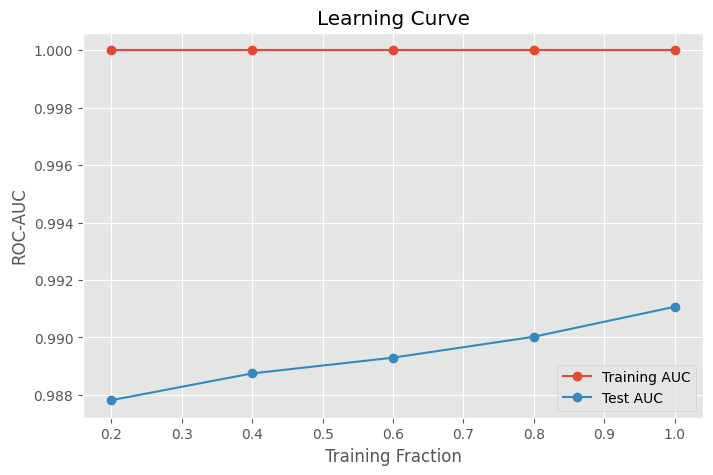

In [35]:
import os

os.makedirs("plots", exist_ok=True)

plt.figure(figsize=(8,5))

plt.plot(

    learning_curve["Training Fraction"],

    learning_curve["Training AUC"],

    marker="o",

    label="Training AUC"

)

plt.plot(

    learning_curve["Training Fraction"],

    learning_curve["Test AUC"],

    marker="o",

    label="Test AUC"

)

plt.xlabel("Training Fraction")

plt.ylabel("ROC-AUC")

plt.title("Learning Curve")

plt.legend()

plt.savefig(

    "plots/learning_curve.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

## Saving the Best Model

The best pipeline obtained from Grid Search is saved to disk using Joblib.

In [36]:
joblib.dump(

    best_pipeline,

    "best_model.pkl"

)

print("Model saved successfully.")

Model saved successfully.


## Loading the Saved Model

The saved model is loaded from disk and used to make predictions on two sample observations.

In [37]:
loaded_model = joblib.load(

    "best_model.pkl"

)

print("Model loaded successfully.")

Model loaded successfully.


## Prediction on Sample Data

Two observations from the test dataset are selected to verify that the saved model can be reloaded and used for prediction.

In [38]:
sample_rows = X_test.iloc[:2]

predictions = loaded_model.predict(

    sample_rows

)

prediction_table = pd.DataFrame({

    "Actual": y_test.iloc[:2].values,

    "Predicted": predictions

})

prediction_table

,Actual,Predicted
0,1,0
1,0,0


## Final Model Comparison

The performance of all classification models is summarized below.

In [42]:
# Logistic Regression Test AUC
logistic_auc = roc_auc_score(
    y_test,
    logistic.predict_proba(X_test_scaled)[:, 1]
)

summary = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "5-Fold Mean AUC": [
        logistic_scores.mean(),
        decision_scores.mean(),
        random_scores.mean(),
        gradient_scores.mean()
    ],

    "5-Fold Std AUC": [
        logistic_scores.std(),
        decision_scores.std(),
        random_scores.std(),
        gradient_scores.std()
    ],

    "Test AUC": [
        logistic_auc,
        roc_auc_score(
            y_test,
            tree_controlled.predict_proba(X_test_scaled)[:, 1]
        ),
        rf_auc,
        gb_auc
    ]

})

print(summary)

                 Model  5-Fold Mean AUC  5-Fold Std AUC  Test AUC
0  Logistic Regression         0.923130        0.010722  0.979208
1        Decision Tree         0.936994        0.009223  0.962120
2        Random Forest         0.982753        0.002151  0.990316
3    Gradient Boosting         0.982390        0.001141  0.990701


## Conclusion

In this notebook, multiple machine learning models were trained and compared using several evaluation techniques.

The Decision Tree models provided a simple baseline, while Random Forest and Gradient Boosting improved predictive performance through ensemble learning.

Cross-validation and Grid Search were used to identify the best-performing model, and the final pipeline was saved using Joblib for future use.

The trained model can now be reloaded without retraining and used directly for predictions, making it suitable for deployment in future applications.

In [43]:
from google.colab import files

files.download("best_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
import shutil

shutil.make_archive(
    "plots",
    "zip",
    "plots"
)

files.download("plots.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>